# Seasonal Agriculture Performance Analysis

## 1. Import Libraries

In this project, Python libraries are used for data manipulation, numerical analysis, statistical analysis, and data visualization.

The main libraries used are Pandas, NumPy, Matplotlib, and Seaborn.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Dataset

The agricultural dataset contains records related to farming activities across different seasons, crops, geographical regions, environmental conditions, irrigation methods, resource usage, production, and economic performance.

The dataset is loaded into a Pandas DataFrame for further analysis.

In [6]:
df = pd.read_csv('seasonal_agriculture_performance_dataset.csv')

## 3. Dataset Overview

Before performing analysis, it is important to understand the structure and characteristics of the dataset.

In this section, the first and last records, dataset dimensions, column names, data types, and statistical summary are examined.

In [7]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [8]:
df.tail()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,...,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,...,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,...,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,...,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,...,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


In [9]:
df.shape

(4000, 28)

In [10]:
df.columns.to_list()

['Farm_ID',
 'State',
 'District',
 'Crop',
 'Season',
 'Farm_Area_Hectares',
 'Rainfall_mm',
 'Avg_Temperature_C',
 'Humidity_pct',
 'Sunlight_Hours_Day',
 'Soil_pH',
 'Soil_Moisture_pct',
 'Nitrogen_kg_ha',
 'Phosphorus_kg_ha',
 'Potassium_kg_ha',
 'Irrigation_Method',
 'Fertilizer_kg_ha',
 'Pesticide_Litre_ha',
 'Seed_Quality_Score',
 'Yield_Tonnes_Ha',
 'Production_Tonnes',
 'Market_Price_INR_Tonne',
 'Total_Cost_INR',
 'Revenue_INR',
 'Profit_INR',
 'Water_Used_m3',
 'Water_Efficiency_t_per_1000m3',
 'Disease_Pest_Risk_pct']

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

In [12]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Farm_ID,4000,4000,SF10001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,4000,8,Andhra Pradesh,529,NaN,NaN,NaN,NaN,NaN,NaN,NaN
District,4000,10,Ludhiana,427,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop,4000,8,Rice,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Season,4000,3,Kharif,1779,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Farm_Area_Hectares,4000.0,NaN,NaN,NaN,7.888265,4.223764,0.5,4.26,7.895,11.65,15.0
Rainfall_mm,3952.0,NaN,NaN,NaN,601.152657,288.925025,80.0,370.2,582.0,834.95,1395.2
Avg_Temperature_C,4000.0,NaN,NaN,NaN,26.8189,3.81818,16.2,23.9,26.9,29.6,39.7
Humidity_pct,4000.0,NaN,NaN,NaN,63.2105,11.960834,25.0,54.775,63.0,71.9,95.0
Sunlight_Hours_Day,4000.0,NaN,NaN,NaN,7.32305,1.121186,3.5,6.6,7.3,8.1,11.0


## 4. Data Cleaning

Data cleaning is an important step in the analysis process because inaccurate, duplicated, or inconsistent records can affect the reliability of the results.

In this section, the dataset is checked for duplicate records and other possible data-quality issues before performing the main analysis.

In [13]:
duplicate_count = df.duplicated().sum()

print('Duplicate Rows:', duplicate_count)

Duplicate Rows: 0


In [14]:
df = df.drop_duplicates().copy()

print('Duplicates remaining:', df.duplicated().sum())

Duplicates remaining: 0


## 5. Missing Values

Missing values can affect statistical calculations and visualizations. Therefore, the dataset is examined to identify columns containing missing observations.

The missing values are analyzed and handled using an appropriate strategy based on the nature of each variable.

In [15]:
missing = pd.DataFrame({
    'Missing Count': df.isna().sum(),
    'Missing %': (df.isna().mean() * 100).round(2)
})

missing = missing[missing['Missing Count'] > 0]

missing.sort_values('Missing Count', ascending=False)

,Missing Count,Missing %
Rainfall_mm,48,1.2
Soil_Moisture_pct,40,1.0
Yield_Tonnes_Ha,32,0.8


In [16]:
df['Rainfall_mm'] = df['Rainfall_mm'].fillna(
    df.groupby('Season')['Rainfall_mm'].transform('median')
)

In [17]:
df['Soil_Moisture_pct'] = df['Soil_Moisture_pct'].fillna(
    df.groupby('Season')['Soil_Moisture_pct'].transform('median')
)

In [18]:
df = df.dropna(subset=['Yield_Tonnes_Ha']).copy()

In [19]:
df.isna().sum()

Farm_ID                          0
State                            0
District                         0
Crop                             0
Season                           0
Farm_Area_Hectares               0
Rainfall_mm                      0
Avg_Temperature_C                0
Humidity_pct                     0
Sunlight_Hours_Day               0
Soil_pH                          0
Soil_Moisture_pct                0
Nitrogen_kg_ha                   0
Phosphorus_kg_ha                 0
Potassium_kg_ha                  0
Irrigation_Method                0
Fertilizer_kg_ha                 0
Pesticide_Litre_ha               0
Seed_Quality_Score               0
Yield_Tonnes_Ha                  0
Production_Tonnes                0
Market_Price_INR_Tonne           0
Total_Cost_INR                   0
Revenue_INR                      0
Profit_INR                       0
Water_Used_m3                    0
Water_Efficiency_t_per_1000m3    0
Disease_Pest_Risk_pct            0
dtype: int64

## 6. Seasonal Distribution

The main focus of this project is to understand how agricultural performance changes across different seasons.

The dataset contains three major seasons: Kharif, Rabi, and Zaid. This section examines the distribution of agricultural records across these seasons.

In [20]:
season_counts = df['Season'].value_counts()

season_counts

Season
Kharif    1772
Rabi      1607
Zaid       589
Name: count, dtype: int64

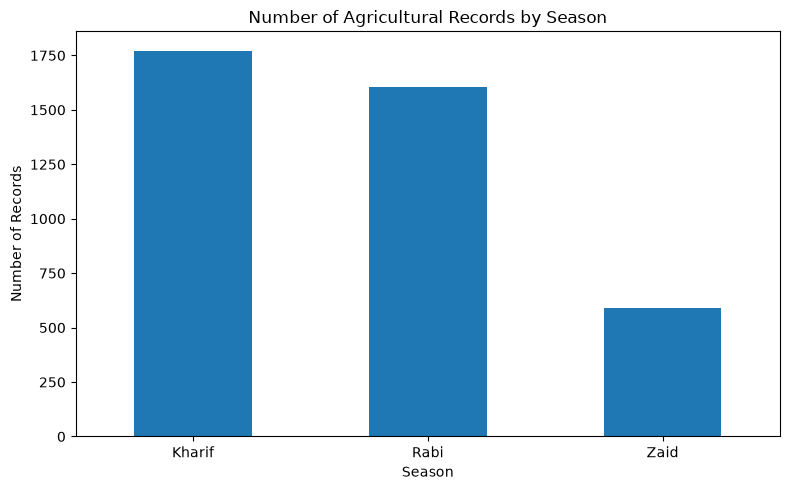

In [21]:
plt.figure(figsize=(8,5))

season_counts.plot(kind='bar')

plt.title('Number of Agricultural Records by Season')
plt.xlabel('Season')
plt.ylabel('Number of Records')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Observation

The dataset contains records from Kharif, Rabi, and Zaid seasons. Kharif has the largest number of observations, followed by Rabi, while Zaid has comparatively fewer observations.

In [22]:
season_performance = df.groupby('Season').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Revenue_INR': 'mean',
    'Total_Cost_INR': 'mean',
    'Profit_INR': 'mean',
    'Water_Used_m3': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean',
    'Disease_Pest_Risk_pct': 'mean'
}).round(2)

season_performance

,Yield_Tonnes_Ha,Revenue_INR,Total_Cost_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Season,,,,,,,
Kharif,5.64,711441.28,532074.15,179367.12,6094.05,5.91,54.47
Rabi,5.08,601825.55,513628.29,88197.25,5837.24,5.18,40.52
Zaid,4.67,516662.12,543254.52,-26592.40,6423.08,4.44,38.22


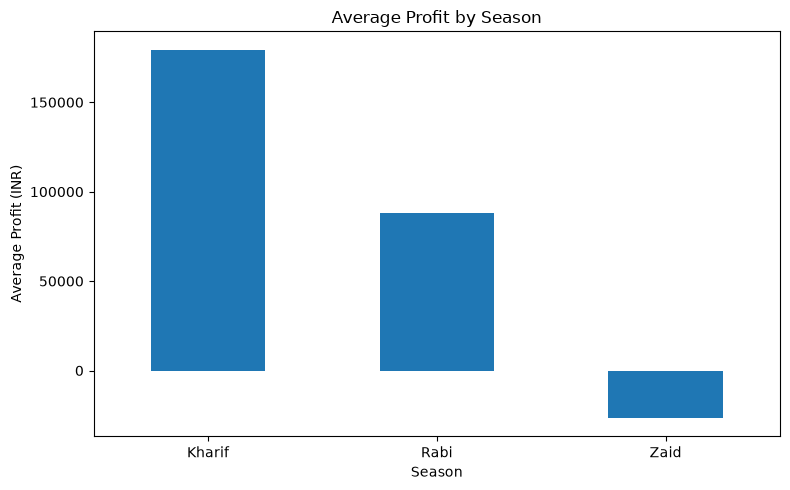

In [23]:
season_profit = df.groupby('Season')['Profit_INR'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))

season_profit.plot(kind='bar')

plt.title('Average Profit by Season')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Average Yield by Season

To understand how agricultural productivity varies across different seasons, the average yield is calculated for Kharif, Rabi, and Zaid seasons.

Yield is measured in tonnes per hectare and is used as an important indicator of agricultural performance.

In [24]:
season_yield = df.groupby('Season')['Yield_Tonnes_Ha'].mean()

season_yield

Season
Kharif    5.643973
Rabi      5.080498
Zaid      4.665942
Name: Yield_Tonnes_Ha, dtype: float64

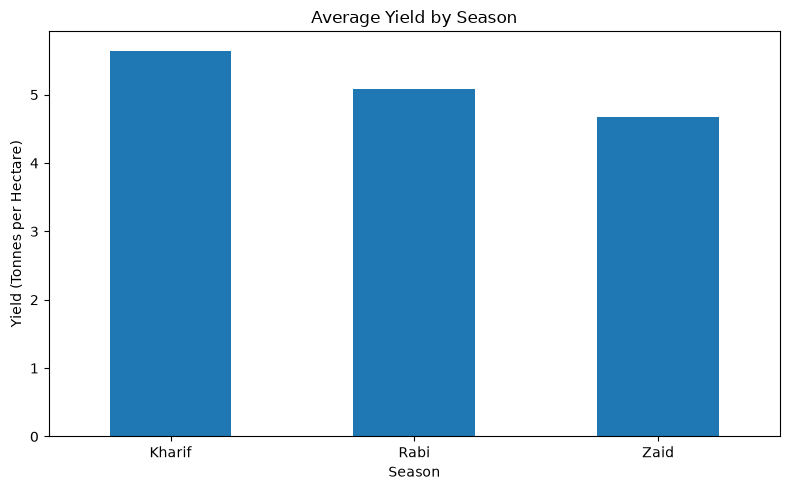

In [41]:
plt.figure(figsize=(8,5))

season_yield.plot(kind='bar')

plt.title('Average Yield by Season')
plt.xlabel('Season')
plt.ylabel('Yield (Tonnes per Hectare)')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Insight

Kharif has the highest average yield among the three seasons, followed by Rabi and Zaid. This indicates that agricultural productivity varies across seasons in the analyzed dataset.

In [25]:
crop_counts = df['Crop'].value_counts()

crop_counts

Crop
Rice         682
Wheat        612
Maize        547
Cotton       504
Pulses       494
Groundnut    419
Chilli       407
Sugarcane    303
Name: count, dtype: int64

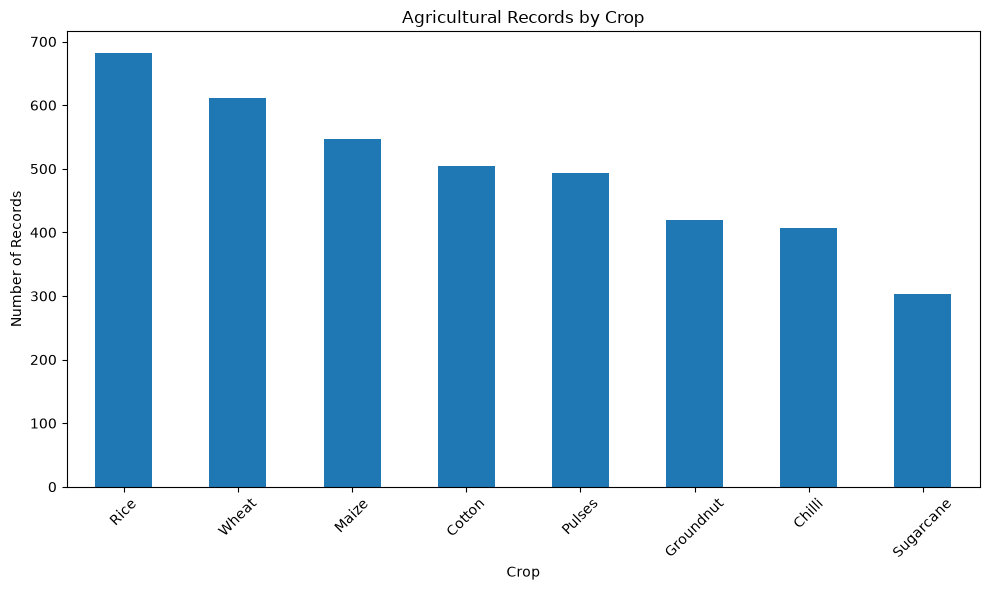

In [26]:
plt.figure(figsize=(10,6))

crop_counts.plot(kind='bar')

plt.title('Agricultural Records by Crop')
plt.xlabel('Crop')
plt.ylabel('Number of Records')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [27]:
crop_profit = df.groupby('Crop')['Profit_INR'].mean().sort_values(ascending=False)

crop_profit

Crop
Sugarcane    817245.399340
Chilli       753377.501229
Cotton       124969.849206
Groundnut     44604.381862
Pulses        -3987.208502
Maize        -82749.433272
Rice        -101405.004399
Wheat       -123567.972222
Name: Profit_INR, dtype: float64

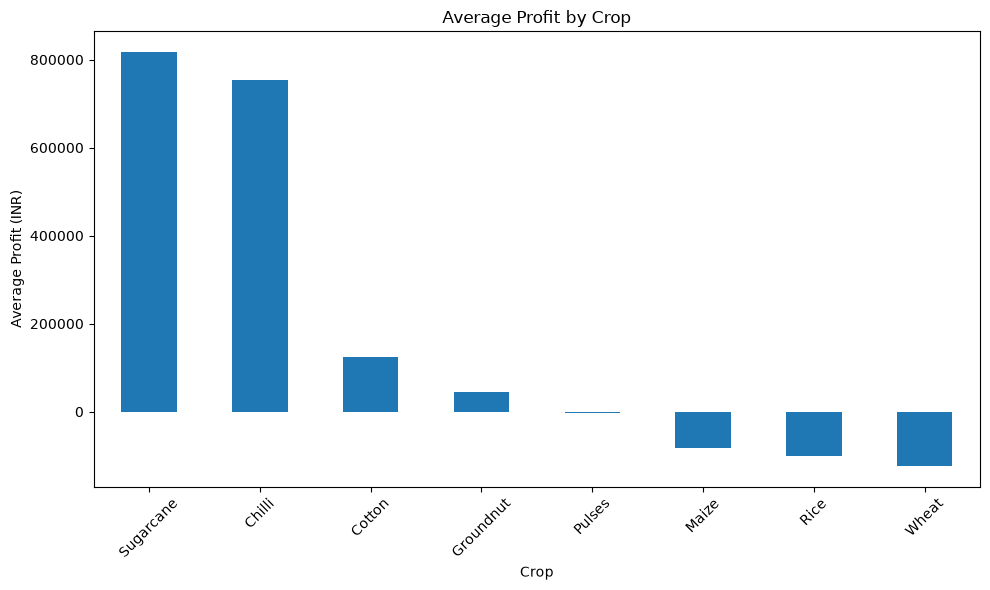

In [28]:
plt.figure(figsize=(10,6))

crop_profit.plot(kind='bar')

plt.title('Average Profit by Crop')
plt.xlabel('Crop')
plt.ylabel('Average Profit (INR)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [29]:
crop_season_profit = pd.pivot_table(
    df,
    values='Profit_INR',
    index='Crop',
    columns='Season',
    aggfunc='mean'
)

crop_season_profit.round(2)

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,959406.84,641572.55,432267.81
Cotton,216142.67,106995.30,-50129.58
Groundnut,108373.54,9252.21,-68872.50
Maize,-39332.67,-87830.88,-191072.20
Pulses,43338.90,-14432.54,-139145.54
Rice,-65529.83,-95167.37,-227239.34
Sugarcane,1000790.81,730402.20,583635.80
Wheat,-106005.81,-120140.46,-193208.95


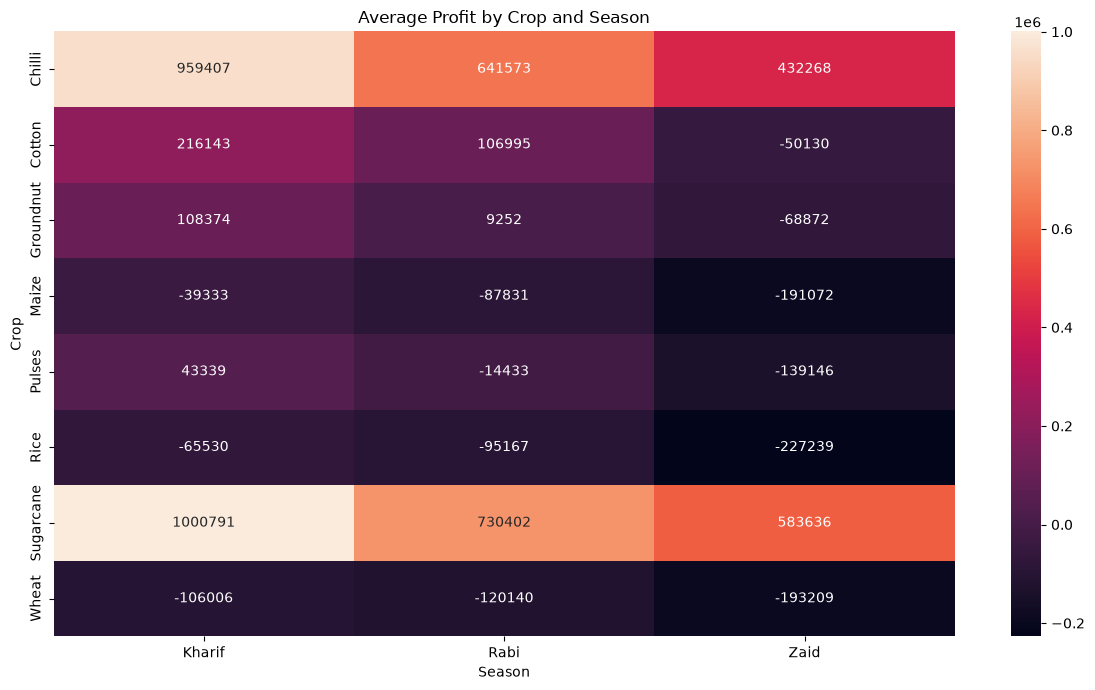

In [30]:
plt.figure(figsize=(12,7))

sns.heatmap(crop_season_profit, annot=True, fmt='.0f')

plt.title('Average Profit by Crop and Season')
plt.xlabel('Season')
plt.ylabel('Crop')

plt.tight_layout()
plt.show()

In [31]:
irrigation_performance = df.groupby('Irrigation_Method').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Profit_INR': 'mean',
    'Water_Used_m3': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean'
}).round(2)

irrigation_performance

,Yield_Tonnes_Ha,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3
Irrigation_Method,,,,
Drip,6.62,219002.41,5901.44,6.23
Flood,4.90,72918.99,8028.81,3.46
Rainfed,4.61,79509.51,3551.55,7.57
Sprinkler,5.19,93844.83,6210.70,4.69


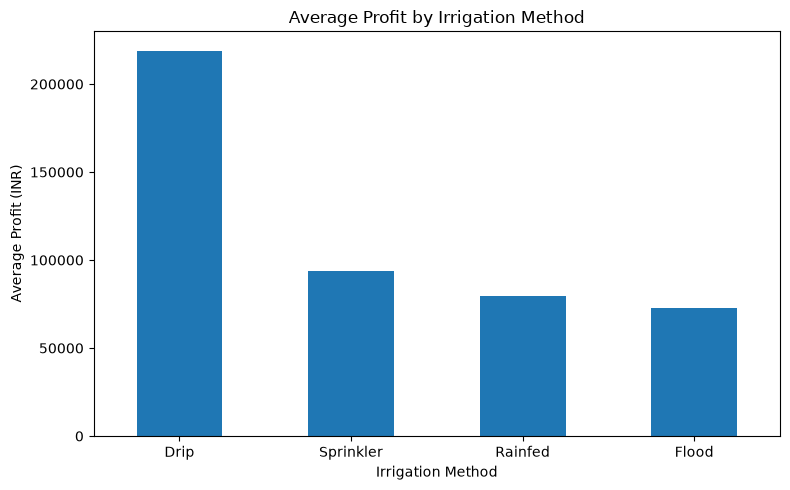

In [32]:
irrigation_profit = df.groupby(
    'Irrigation_Method'
)['Profit_INR'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))

irrigation_profit.plot(kind='bar')

plt.title('Average Profit by Irrigation Method')
plt.xlabel('Irrigation Method')
plt.ylabel('Average Profit (INR)')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [33]:
environment = df.groupby('Season').agg({
    'Rainfall_mm': 'mean',
    'Avg_Temperature_C': 'mean',
    'Humidity_pct': 'mean',
    'Soil_Moisture_pct': 'mean',
    'Sunlight_Hours_Day': 'mean'
}).round(2)

environment

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Soil_Moisture_pct,Sunlight_Hours_Day
Season,,,,,
Kharif,851.61,28.45,71.84,31.20,6.79
Rabi,436.23,23.50,57.92,24.08,7.59
Zaid,298.67,31.05,51.99,19.16,8.18


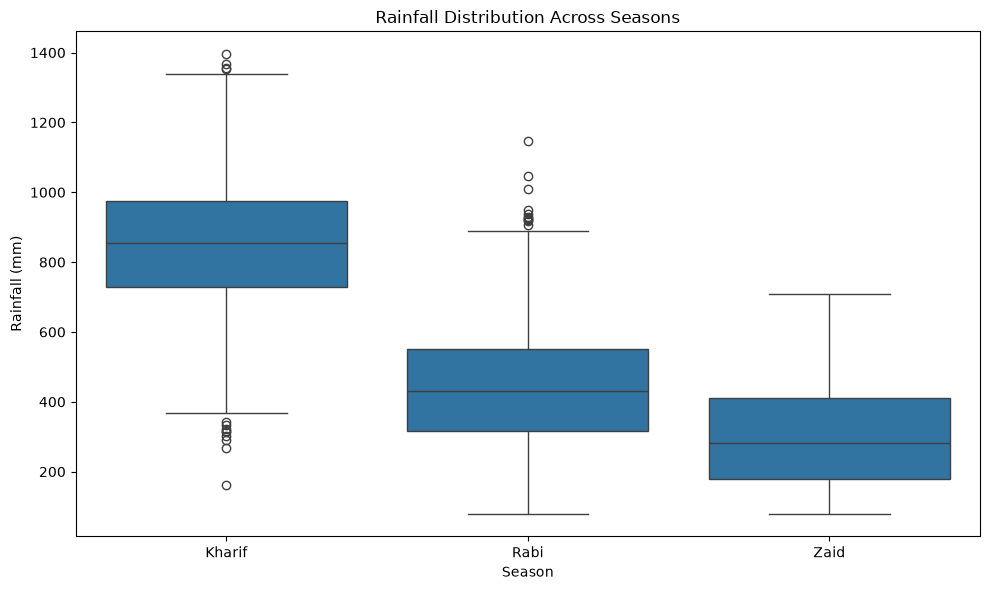

In [34]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='Season',
    y='Rainfall_mm',
    data=df
)

plt.title('Rainfall Distribution Across Seasons')
plt.xlabel('Season')
plt.ylabel('Rainfall (mm)')

plt.tight_layout()
plt.show()

In [35]:
numeric_columns = [
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Soil_Moisture_pct',
    'Nitrogen_kg_ha',
    'Phosphorus_kg_ha',
    'Potassium_kg_ha',
    'Fertilizer_kg_ha',
    'Pesticide_Litre_ha',
    'Yield_Tonnes_Ha',
    'Water_Used_m3',
    'Profit_INR'
]

correlation = df[numeric_columns].corr()

correlation

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Yield_Tonnes_Ha,Water_Used_m3,Profit_INR
Rainfall_mm,1.000000,0.197085,0.528005,0.520687,0.005515,0.019141,0.033842,0.025215,0.001270,0.028344,0.003985,0.107555
Avg_Temperature_C,0.197085,1.000000,0.135647,0.080294,0.019061,0.009856,0.023390,0.014632,0.005984,0.009349,0.022794,0.006613
Humidity_pct,0.528005,0.135647,1.000000,0.451747,0.000179,-0.006033,-0.002573,0.025713,-0.003456,0.011277,-0.004049,0.064986
Soil_Moisture_pct,0.520687,0.080294,0.451747,1.000000,0.007749,0.012787,0.008668,0.008063,-0.020976,0.010160,0.004260,0.093641
Nitrogen_kg_ha,0.005515,0.019061,0.000179,0.007749,1.000000,0.010305,0.010133,-0.031473,0.015019,0.053867,0.022687,0.087748
Phosphorus_kg_ha,0.019141,0.009856,-0.006033,0.012787,0.010305,1.000000,0.003921,0.013642,-0.029602,0.047821,0.002425,0.049520
Potassium_kg_ha,0.033842,0.023390,-0.002573,0.008668,0.010133,0.003921,1.000000,0.015951,-0.002836,0.003836,-0.000758,0.030737
Fertilizer_kg_ha,0.025215,0.014632,0.025713,0.008063,-0.031473,0.013642,0.015951,1.000000,-0.001022,0.000562,0.000210,-0.073645
Pesticide_Litre_ha,0.001270,0.005984,-0.003456,-0.020976,0.015019,-0.029602,-0.002836,-0.001022,1.000000,-0.007650,0.002503,-0.026809
Yield_Tonnes_Ha,0.028344,0.009349,0.011277,0.010160,0.053867,0.047821,0.003836,0.000562,-0.007650,1.000000,0.388653,0.489822


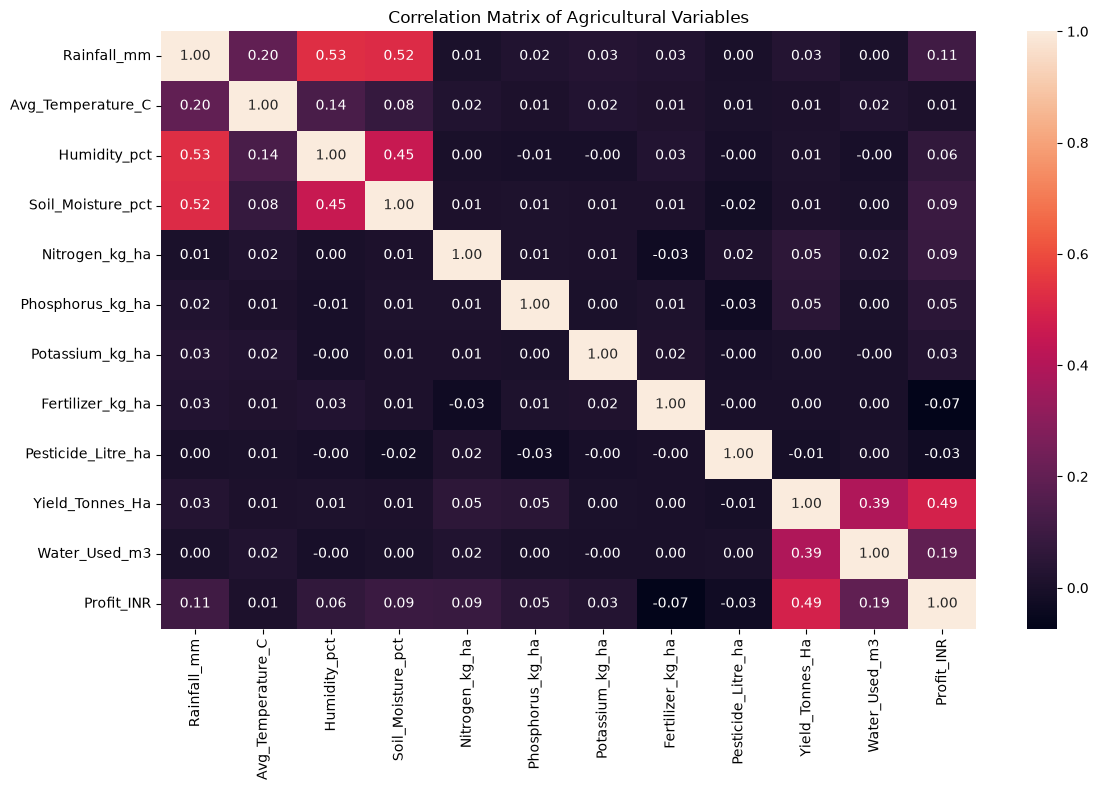

In [36]:
plt.figure(figsize=(12,8))

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f'
)

plt.title('Correlation Matrix of Agricultural Variables')

plt.tight_layout()
plt.show()

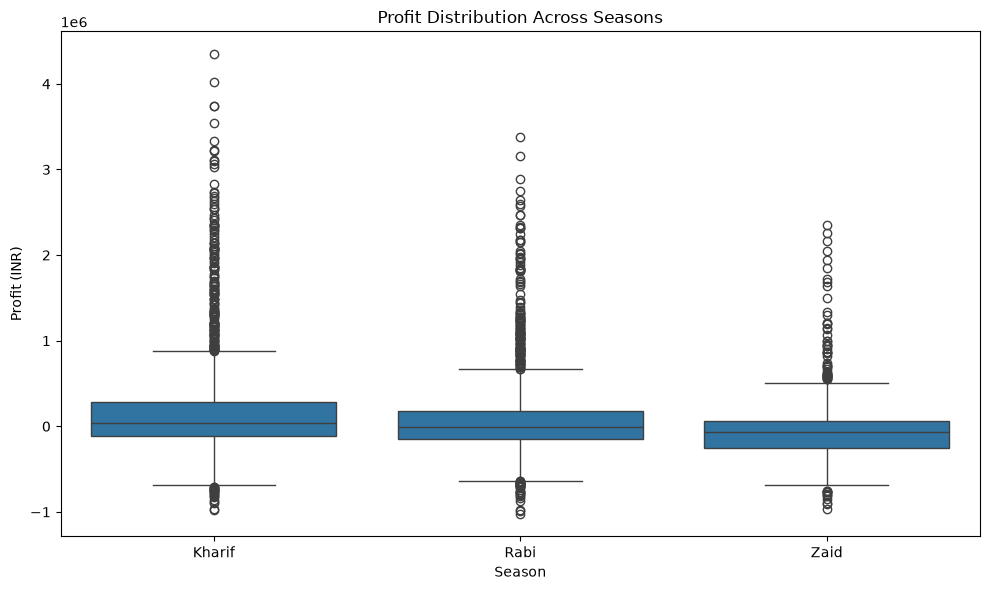

In [37]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='Season',
    y='Profit_INR',
    data=df
)

plt.title('Profit Distribution Across Seasons')
plt.xlabel('Season')
plt.ylabel('Profit (INR)')

plt.tight_layout()
plt.show()

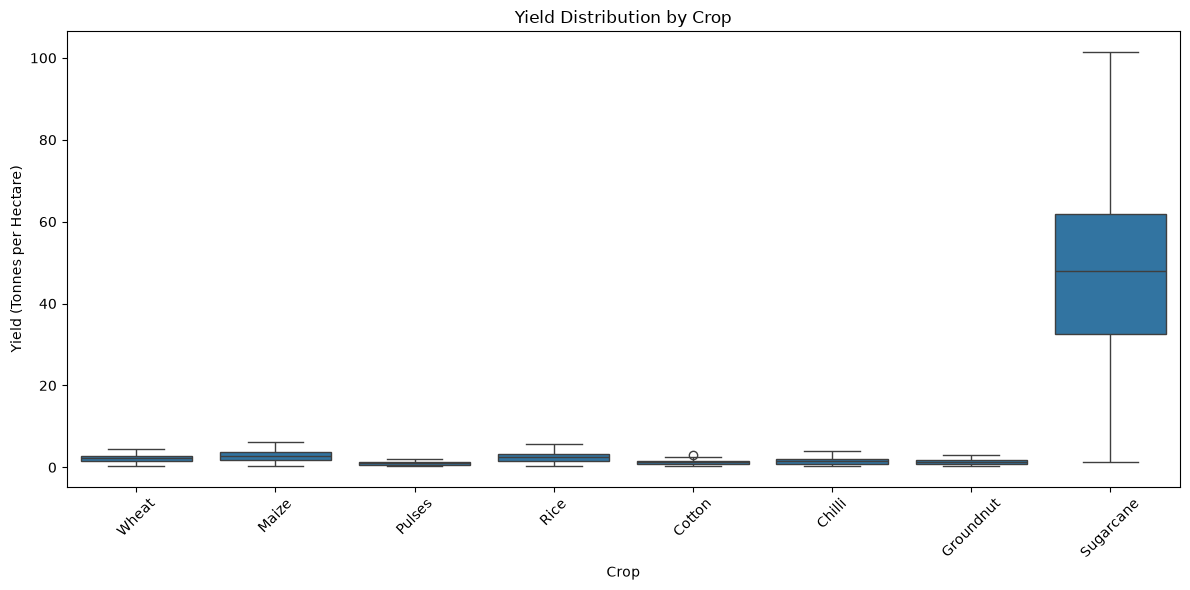

In [38]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x='Crop',
    y='Yield_Tonnes_Ha',
    data=df
)

plt.title('Yield Distribution by Crop')
plt.xlabel('Crop')
plt.ylabel('Yield (Tonnes per Hectare)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

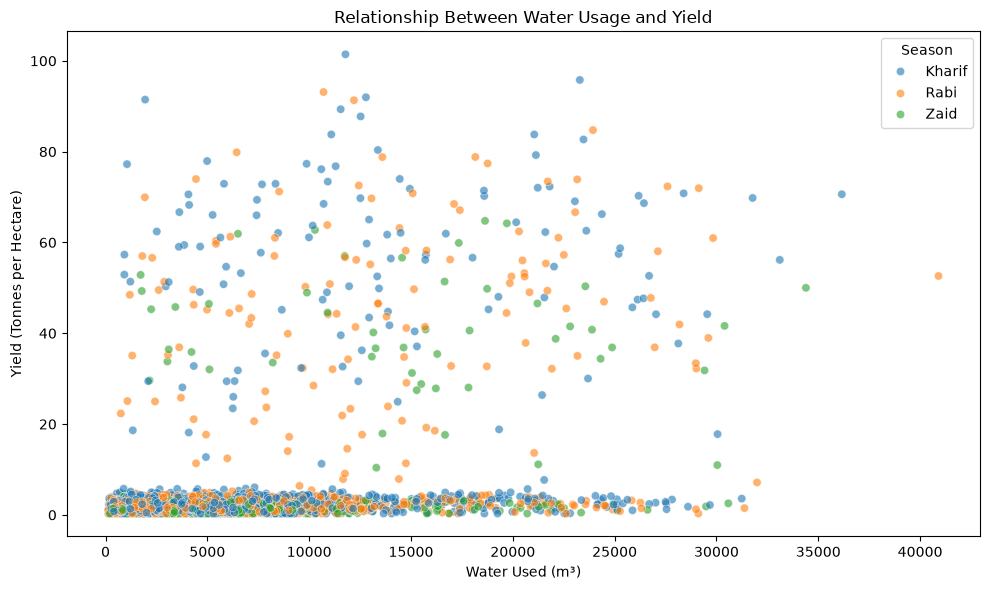

In [39]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Water_Used_m3',
    y='Yield_Tonnes_Ha',
    hue='Season',
    data=df,
    alpha=0.6
)

plt.title('Relationship Between Water Usage and Yield')
plt.xlabel('Water Used (m³)')
plt.ylabel('Yield (Tonnes per Hectare)')

plt.tight_layout()
plt.show()

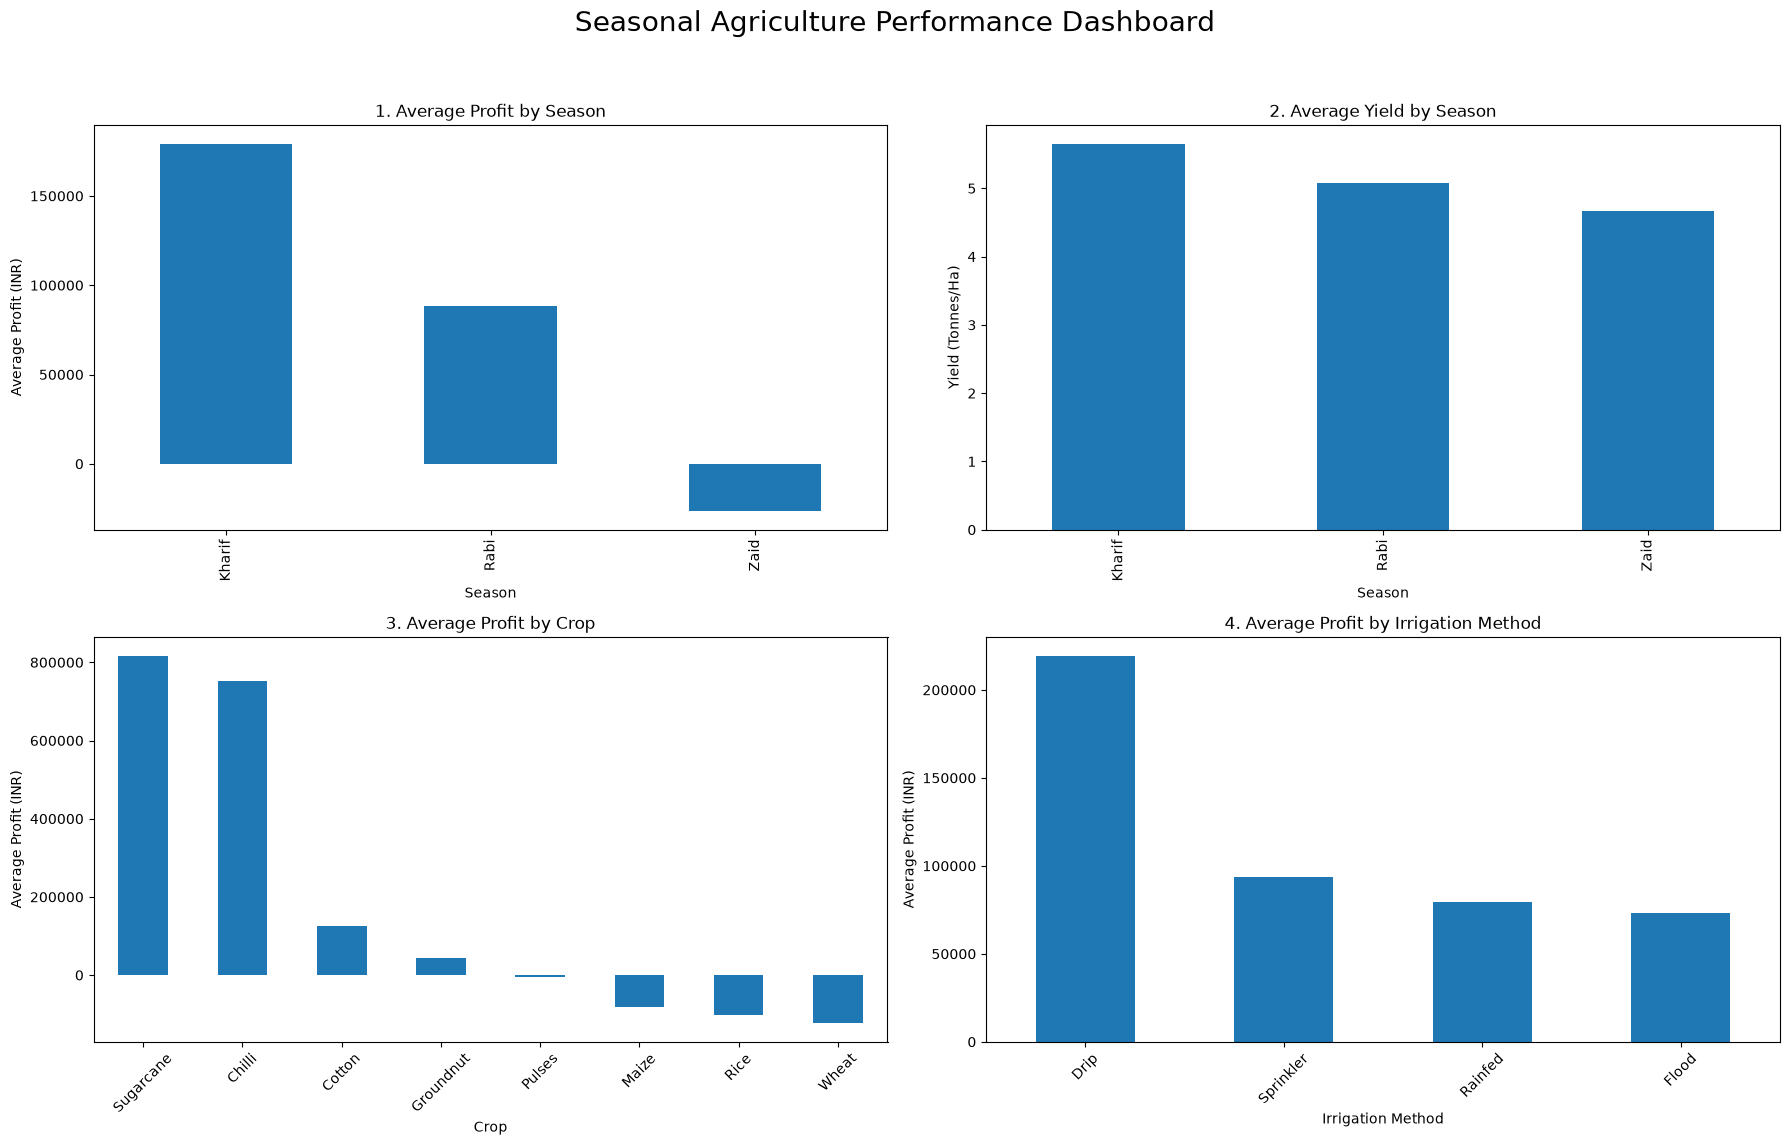

In [40]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

fig.suptitle(
    'Seasonal Agriculture Performance Dashboard',
    fontsize=20
)

# 1. Profit by Season
season_profit.plot(
    kind='bar',
    ax=axes[0, 0]
)

axes[0, 0].set_title('1. Average Profit by Season')
axes[0, 0].set_xlabel('Season')
axes[0, 0].set_ylabel('Average Profit (INR)')


# 2. Yield by Season
season_yield = df.groupby('Season')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False)

season_yield.plot(
    kind='bar',
    ax=axes[0, 1]
)

axes[0, 1].set_title('2. Average Yield by Season')
axes[0, 1].set_xlabel('Season')
axes[0, 1].set_ylabel('Yield (Tonnes/Ha)')


# 3. Profit by Crop
crop_profit.plot(
    kind='bar',
    ax=axes[1, 0]
)

axes[1, 0].set_title('3. Average Profit by Crop')
axes[1, 0].set_xlabel('Crop')
axes[1, 0].set_ylabel('Average Profit (INR)')
axes[1, 0].tick_params(axis='x', rotation=45)


# 4. Profit by Irrigation
irrigation_profit.plot(
    kind='bar',
    ax=axes[1, 1]
)

axes[1, 1].set_title('4. Average Profit by Irrigation Method')
axes[1, 1].set_xlabel('Irrigation Method')
axes[1, 1].set_ylabel('Average Profit (INR)')
axes[1, 1].tick_params(axis='x', rotation=45)


plt.tight_layout(
    rect=[0, 0.03, 1, 0.95]
)

plt.show()

## 15. Key Findings

The analysis of the Seasonal Agriculture Performance dataset resulted in the following key findings:

1. **Kharif is the best-performing season overall**, showing the highest average yield, revenue, and profit among the three seasons.

2. **Rabi shows moderate agricultural performance**, with average yield, revenue, and profit falling between Kharif and Zaid for the major performance indicators.

3. **Zaid has the weakest economic performance**, recording the lowest average yield and revenue and a negative average profit.

4. **Kharif has the highest average water efficiency**, indicating stronger production relative to water usage in the analyzed dataset.

5. **Disease and pest risk is highest during Kharif**, despite Kharif showing the strongest overall agricultural and economic performance.

6. **Crop profitability varies considerably**, with Sugarcane and Chilli showing the strongest average profitability among the crops analyzed.

7. **Wheat, Rice, and Maize show comparatively weaker profitability**, with several crop-season combinations recording negative average profits.

8. **Crop performance varies across seasons**, showing that the same crop can have different yield and profitability depending on the season.

9. **Drip irrigation shows strong agricultural performance**, with the highest average yield and average profit among the irrigation methods analyzed.

10. **Environmental conditions vary significantly across seasons**, with Kharif having higher rainfall, humidity, and soil moisture, while Zaid has higher temperature and lower rainfall and soil moisture.

11. **Yield, production, water usage, and economic variables show relationships in the correlation analysis**, while environmental variables such as rainfall and temperature show relatively weak linear relationships with yield.

12. **Overall agricultural performance depends on multiple factors**, including season, crop selection, irrigation method, environmental conditions, resource usage, production, and economic factors.

## 17. Conclusion

This project analyzed the performance of agricultural activities across different seasons using data related to crops, environmental conditions, irrigation methods, resource usage, production, and economic outcomes.

The analysis identified clear differences between Kharif, Rabi, and Zaid seasons. Kharif showed the strongest overall agricultural and economic performance, while Zaid showed the weakest average profitability in the analyzed dataset.

The study also found considerable differences in performance between crops and crop-season combinations. Sugarcane and Chilli showed strong average profitability, while some crops such as Wheat, Rice, and Maize showed weaker economic performance in certain seasonal conditions.

Irrigation analysis showed that Drip irrigation had strong average yield and profit performance. Environmental analysis also showed noticeable differences in rainfall, temperature, humidity, and soil moisture across seasons.

Overall, the project demonstrates how data analytics and visualization can be used to identify seasonal patterns, compare agricultural performance, examine resource usage, and generate evidence-based insights for agricultural planning.

The findings are based on the available dataset and describe observed patterns and relationships. They should therefore be used as analytical insights rather than as proof of direct causal relationships.